In [1]:
# Check pytorch version
import torch

print(torch.__version__)

2.5.1


In [2]:
!nvidia-smi

Mon Nov 25 00:41:44 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.59                 Driver Version: 556.13         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   55C    P8              6W /   75W |     607MiB /   8188MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available")

Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# Use GPU for training
device = torch.device("cuda")

In [5]:
_exp_name = 'mnist'

In [6]:
# Import necessary packages
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from omegaconf import OmegaConf
from tqdm.auto import tqdm

/home/patchouli/miniconda3/envs/cuda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Fix random seed for reproducibility
seed = 114514
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Avoid nondeterministic algorithms and disable benchmarks for convolution operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
from torchvision import datasets, transforms

# Pipeline for preprocessing of the image. 
transform = transforms.Compose([

    # Resize into a fixed size
    transforms.Resize((128, 128)),

    # Transform to pytorch tensor
    transforms.ToTensor(),

    # Normalizes the pixel values to have a mean value of 0 and a standard deviation of 1, assuming initially in range (0, 1)
    transforms.Normalize((0.5,), (0.5,))
])

# Download the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


Train dataset has 60000 samples.
Test dataset has 10000 samples.


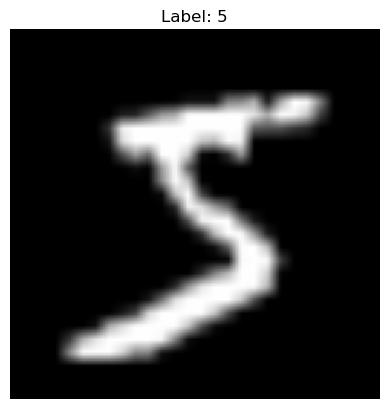

In [9]:
print(f'Train dataset has {len(train_dataset)} samples.')
print(f'Test dataset has {len(test_dataset)} samples.')

# Viualization of the first image
image_zero, target_zero = train_dataset[0]
plt.imshow(image_zero.squeeze().numpy(), cmap="gray")
plt.title(f"Label: {target_zero}")
plt.axis("off")
plt.show()

In [15]:
class Classfier(nn.Module):
    def __init__(self):
        # inherit attributes and methods of nn.Module
        super(Classfier, self).__init__()

        self.cnn = nn.Sequential(
            # Input size is [128, 128, 1]
            self.cnn_layer(in_channels=1, out_channels=64),     # [64, 64, 64]

            self.cnn_layer(in_channels=64, out_channels=128),       # [32, 32, 128]

            self.cnn_layer(in_channels=128, out_channels=256),      # [16, 16, 256]

            self.cnn_layer(in_channels=256, out_channels=512),       # [8, 8, 512]

            self.cnn_layer(in_channels=512, out_channels=512)       # [4, 4, 512]
        )

        self.fc = nn.Sequential(
            nn.Linear(512*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
            nn.Softmax(dim=1)
        )

    def cnn_layer(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, 
                  pooling_kernel_size=2, pooling_stride=2, pooling_padding=0):
        """
        Create a default CNN layer. In and out channels are required parameters
        Parameters:
        - in_channels: Number of input channels.
        - out_channels: Number of output filter channels.
        - kernel_size: Size of the convolutional kernel.
        - stride: Stride of the convolution.
        - padding: Padding value added to the input.
        - pooling_kernel_size: Size of the maxpooling kernel.
        - pooling_stride: Stride of the maxpooling.
        - pooing_padding: Padding value added to the convolution output channel.

        Returns:
        - nn.Sequential: A block with convolution layer and pooling layer.
        """

        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels, eps=1e-05, momentum=0.1),
            nn.ReLU(),
            nn.MaxPool2d(pooling_kernel_size, pooling_stride, pooling_padding)
        )
    
    def forward(self, x):

        filter = self.cnn(x)
        filter = filter.view(filter.size(0), -1)

        return self.fc(filter)

In [16]:
config = OmegaConf.load('config.yaml')
config_dict = OmegaConf.to_container(config, resolve=True)

In [17]:
# Divide MNIST dataset into training, vaildation and test sets

# 48,000 figures as training data, 12,000 figures as validation data
train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train, valid = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train, batch_size=config_dict['batch_size'], shuffle=True)
valid_loader = DataLoader(valid, batch_size=config_dict['batch_size'], shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=config_dict['batch_size'], shuffle=True, pin_memory=True)

In [18]:
# Initiallize the model to device
model = Classfier().to(device)

# Set up loss function and optimizer
criterion = getattr(nn, config_dict['criterion'])()

optimizer = torch.optim.Adam(model.parameters(), lr = config_dict['lr'], weight_decay=config_dict['weight_decay'])

patience = config_dict['patience']

In [19]:
"""
Start training
"""
n_epoches = config_dict['n_epoches']
stale = 0
best_acc = 0

for epoch in range(n_epoches):

    """ -----  Training  ----- """

    # Turn to train mode
    model.train()

    train_loss = []
    train_accs = []

    for batch in tqdm(train_loader):

        # Load data and label to device
        data, label = batch
        data, label = data.to(device), label.to(device)

        # Clear gradient buffers
        optimizer.zero_grad()

        # Forward propagation
        output = model(data)

        # Compute loss
        loss = criterion(output, label)

        # Backward propagation
        loss.backward()

        # Clip the gradient norms for stable training
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

        # Update the parameters
        optimizer.step()

        # Compute the accuracy for current batch
        acc = (output.argmax(dim=-1) == label).float().mean()

        # Record the loss and accuracy
        train_loss.append(loss.item())
        train_accs.append(acc)
    
    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)

    # Print the information.
    print(f"[ Train | {epoch + 1:03d}/{n_epoches:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")


    """ -----  Validation  ----- """
    # Turn to validation mode
    model.eval()

    valid_loss = []
    valid_accs = []

    for batch in tqdm(valid_loader):

        data, label = batch
        data, label = data.to(device), label.to(device)

        # No need for gradient computation, so acclerate by no_grad
        with torch.no_grad():
            
            output = model(data)

        loss = criterion(output, label)
        acc = (output.argmax(dim=-1) == label.to(device)).float().mean()

        valid_loss.append(loss.item())
        valid_accs.append(acc)

    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc = sum(valid_accs) / len(valid_accs)

    # Print the information.
    print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

    # update logs
    if valid_acc > best_acc:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f} -> best")
    else:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")


    # save models
    if valid_acc > best_acc:
        print(f"Best model found at epoch {epoch}, saving model")
        torch.save(model.state_dict(), f"{_exp_name}_best.ckpt") # only save best to prevent output memory exceed error
        best_acc = valid_acc
        stale = 0
    else:
        stale += 1
        if stale > patience:
            print(f"No improvment {patience} consecutive epochs, early stopping")
            break


100%|██████████| 750/750 [01:32<00:00,  8.12it/s]


[ Train | 001/005 ] loss = 2.22341, acc = 0.23544


100%|██████████| 188/188 [00:08<00:00, 22.85it/s]


[ Valid | 001/005 ] loss = 1.89343, acc = 0.56724
[ Valid | 001/005 ] loss = 1.89343, acc = 0.56724 -> best
Best model found at epoch 0, saving model


100%|██████████| 750/750 [01:32<00:00,  8.07it/s]


...

[ Valid | 004/005 ] loss = 1.88563, acc = 0.57547
[ Valid | 004/005 ] loss = 1.88563, acc = 0.57547


100%|██████████| 750/750 [01:32<00:00,  8.13it/s]


[ Train | 005/005 ] loss = 1.78943, acc = 0.67167


100%|██████████| 188/188 [00:08<00:00, 22.20it/s]

[ Valid | 005/005 ] loss = 1.73503, acc = 0.72598
[ Valid | 005/005 ] loss = 1.73503, acc = 0.72598 -> best
Best model found at epoch 4, saving model
